# 03 · Learning curves and uncertainty

Reads only `results/03_learning_curves/` and `results/03_uncertainty/` (written by
`experiments/03_*.py`); nothing is fitted and no API is called here. XGBoost learning curves and
uncertainty baselines were run off-Mac; `machines.json` records which machine ran each result.
Every number is printed from the result files.

In [1]:
import json
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

LC = Path("../results/03_learning_curves")
UNC = Path("../results/03_uncertainty")
FIG = UNC / "figures"
SIZES = ["100", "300", "1000", "3000", "10000", "full"]
curves = pd.read_csv(LC / "curves.csv", dtype={"n_label": str})
cal = pd.read_csv(UNC / "calibration.csv")

## 1. Learning curves (grouped splits 0-4, nested training subsets, fixed test sets)

n_label                     100    300   1000   3000  10000   full
features    model                                                 
composition tabpfn        17.53  15.34  13.10  11.08   9.33   8.94
            xgb_hamidieh    NaN    NaN    NaN    NaN    NaN  10.01
            xgb_tuned       NaN    NaN    NaN    NaN    NaN   9.82
engineered  tabpfn        18.59  15.15  12.95  11.18   9.44   9.06
            xgb_hamidieh    NaN    NaN    NaN    NaN    NaN   9.77
            xgb_tuned       NaN    NaN    NaN    NaN    NaN   9.70

,features,n_label,b,n_splits,mean_diff,std_diff,a_better_splits,b_better_splits
0,composition,full,xgb_tuned,5,-0.887,0.141,5,0
1,composition,full,xgb_hamidieh,5,-1.071,0.051,5,0
2,engineered,full,xgb_tuned,5,-0.644,0.057,5,0
3,engineered,full,xgb_hamidieh,5,-0.712,0.089,5,0


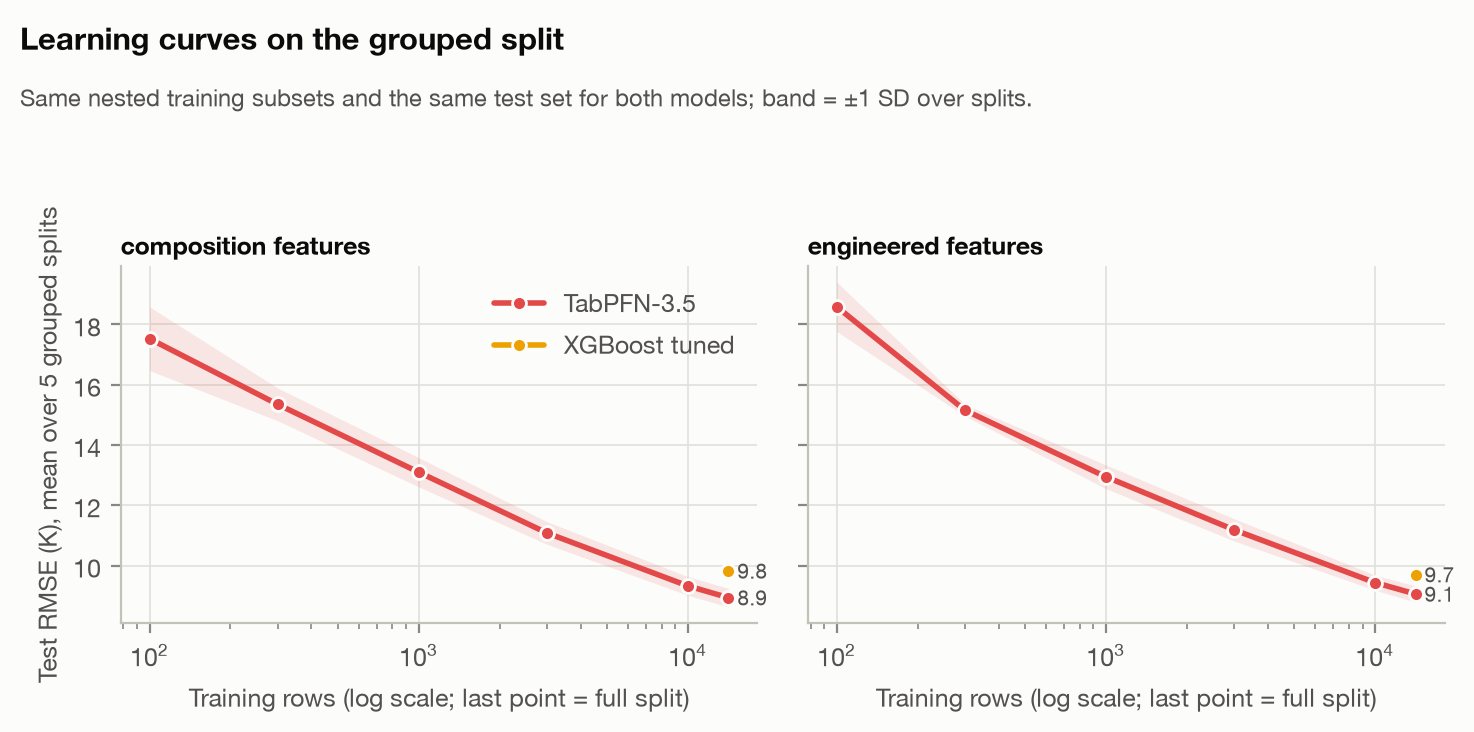

{}

In [2]:
rmse = curves.pivot_table(index=["features", "model"], columns="n_label", values="rmse")
display(rmse.reindex(columns=SIZES).round(2))
paired = pd.read_csv(LC / "paired.csv", dtype={"n_label": str})
display(paired.round(3))
display(Image(FIG / "learning_curves.png"))
json.loads((LC / "machines.json").read_text())

## 2. Accuracy of the quantile-grid summaries
Exact values from TabPFN's full output vs the committed 107-level grid summaries, 400 rows on
each of two grouped splits.

In [3]:
pd.DataFrame(json.loads((UNC / "quantile_vs_full.json").read_text()))

,split_00,split_01
rows,400,400
mean_full_vs_phase2_K,"{'max': 0.014087677001953125, 'median': 0.0014...","{'max': 0.013263702392578125, 'median': 0.0018..."
crps_exact_vs_grid_K,"{'max': 0.072915209293825, 'median': 0.0009086...","{'max': 0.05198641748945221, 'median': 0.00071..."
crps_mean_exact_vs_grid_K,"[6.178780183602573, 6.179863929748535]","[5.62844178969553, 5.629215240478516]"
pit_exact_vs_grid,"{'max': 0.004795926303685638, 'median': 8.1099...","{'max': 0.004763690004040533, 'median': 7.2070..."
p_above_77K_exact_vs_grid,"{'max': 0.004970759822218618, 'median': 0.0001...","{'max': 0.004957259462738617, 'median': 0.0001..."
p_above_77K_exact_below_grid_floor,72,79
quantiles_exact_vs_grid_K,"{'max': 0.03331413998285626, 'median': 0.00126...","{'max': 0.02862463683074168, 'median': 0.00122..."


## 3. Interval coverage, width and CRPS
Averaged over splits. `crps` uses TabPFN's 100-level grid; `crps20` uses the 20-level grid that
the XGBoost baselines are scored on (TabPFN on the same levels).

In [4]:
cols = [
    "coverage_50%",
    "coverage_80%",
    "coverage_90%",
    "coverage_95%",
    "width_80%",
    "width_95%",
    "crps",
    "crps20",
    "rmse",
]
allrows = cal[(cal.group == "all") & (cal.kind != "leave_family_out")]
allrows.set_index(["kind", "features", "model"])[cols].round(3)

coverage_50%  coverage_80%  \
kind              features    model                                
random            engineered  tabpfn         0.538         0.817   
                  composition tabpfn         0.548         0.829   
grouped           engineered  tabpfn         0.530         0.813   
                  composition tabpfn         0.540         0.825   
grouped_no_oxygen engineered  tabpfn         0.522         0.801   
                  composition tabpfn         0.537         0.822   

                                      coverage_90%  coverage_95%  width_80%  \
kind              features    model                                           
random            engineered  tabpfn         0.906         0.952     14.485   
                  composition tabpfn         0.915         0.957     15.043   
grouped           engineered  tabpfn         0.906         0.952     15.425   
                  composition tabpfn         0.915         0.958     15.966   
grouped_no_oxygen engineered  tabpfn         0.897         0.950     15.888   
                  composition tabpfn         0.913         0.957     16.800   

                                      width_95%   crps  crps20    rmse  
kind              features    model                                     
random            engineered  tabpfn     24.884  3.252     NaN   8.713  
                  composition tabpfn     25.693  3.281     NaN   8.702  
grouped           engineered  tabpfn     26.422  3.445   3.453   9.007  
                  composition tabpfn     27.294  3.444   3.451   8.968  
grouped_no_oxygen engineered  tabpfn     27.654  4.023     NaN  10.484  
                  composition tabpfn     28.558  3.801     NaN   9.929

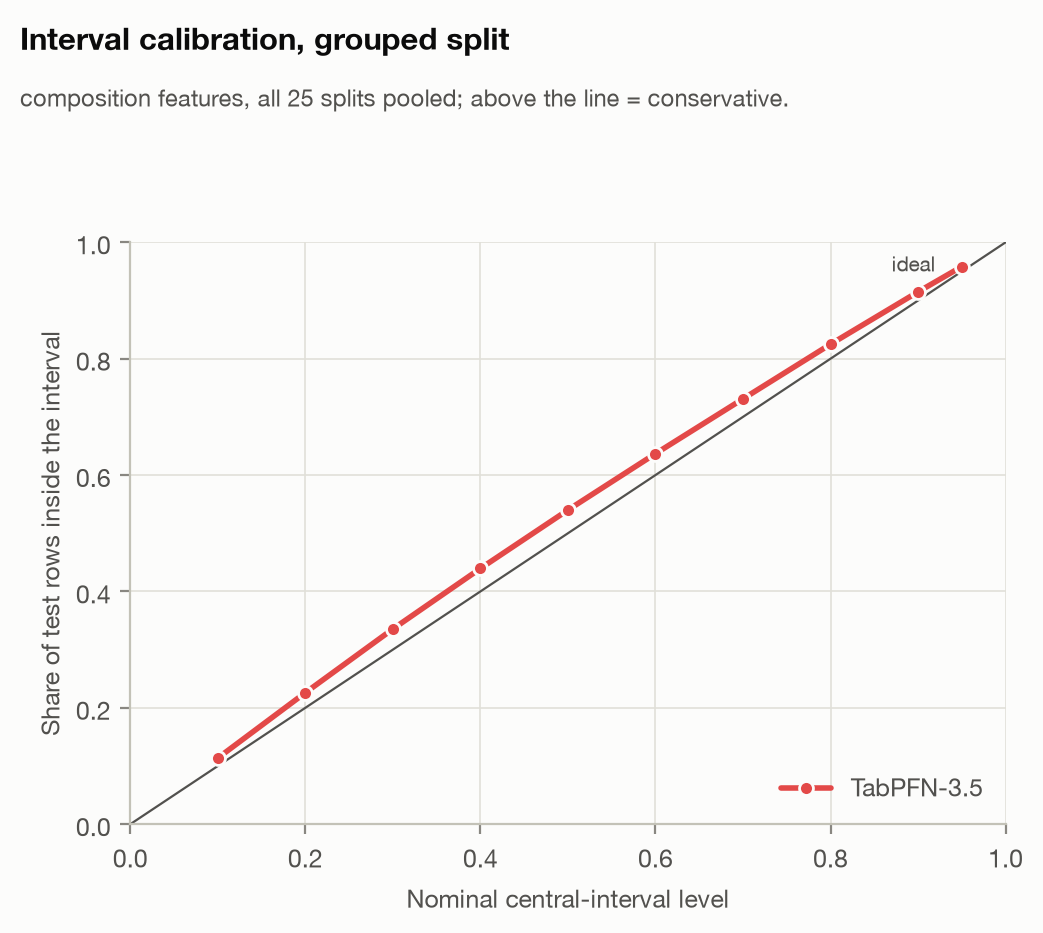

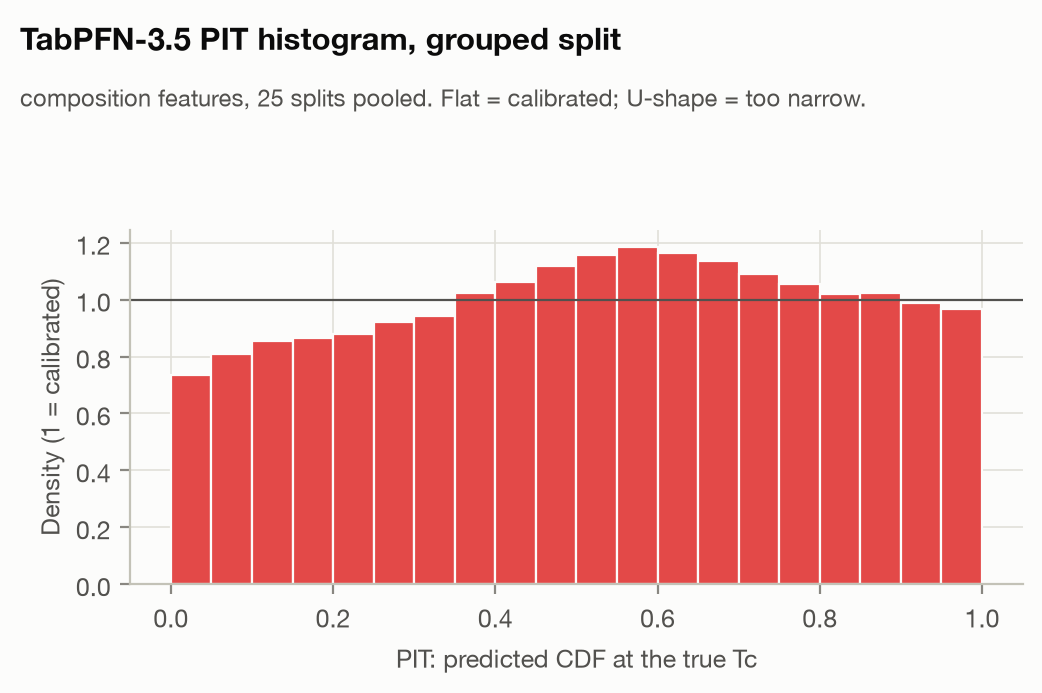

In [5]:
display(Image(FIG / "calibration_curve.png"))
display(Image(FIG / "pit_hist.png"))

## 4. Coverage by Tc band, family and missing-oxygen rows (grouped split)

In [6]:
g = cal[(cal.kind == "grouped") & (cal.features == "composition")]
g.pivot_table(index="group", columns="model", values=["coverage_95%", "width_95%"]).round(3)

,coverage_95%,width_95%
model,tabpfn,tabpfn
group,,
10-77 K,0.960,35.279
Tc < 10 K,0.961,9.281
Tc > 77 K,0.950,43.122
all,0.958,27.294
family: cuprate,0.956,42.942
family: iron-based,0.954,24.952
family: other,0.962,9.391
oxygen amount missing,0.962,51.242


## 5. Is P(Tc > 77 K) reliable?

,model,kind,features,brier,base_rate_brier
0,tabpfn,random,engineered,0.0355,0.1497
1,tabpfn,random,composition,0.0358,0.1497
2,tabpfn,grouped,engineered,0.0369,0.1500
3,tabpfn,grouped,composition,0.0369,0.1500
4,tabpfn,grouped_no_oxygen,engineered,0.0499,0.1554
5,tabpfn,grouped_no_oxygen,composition,0.0442,0.1554


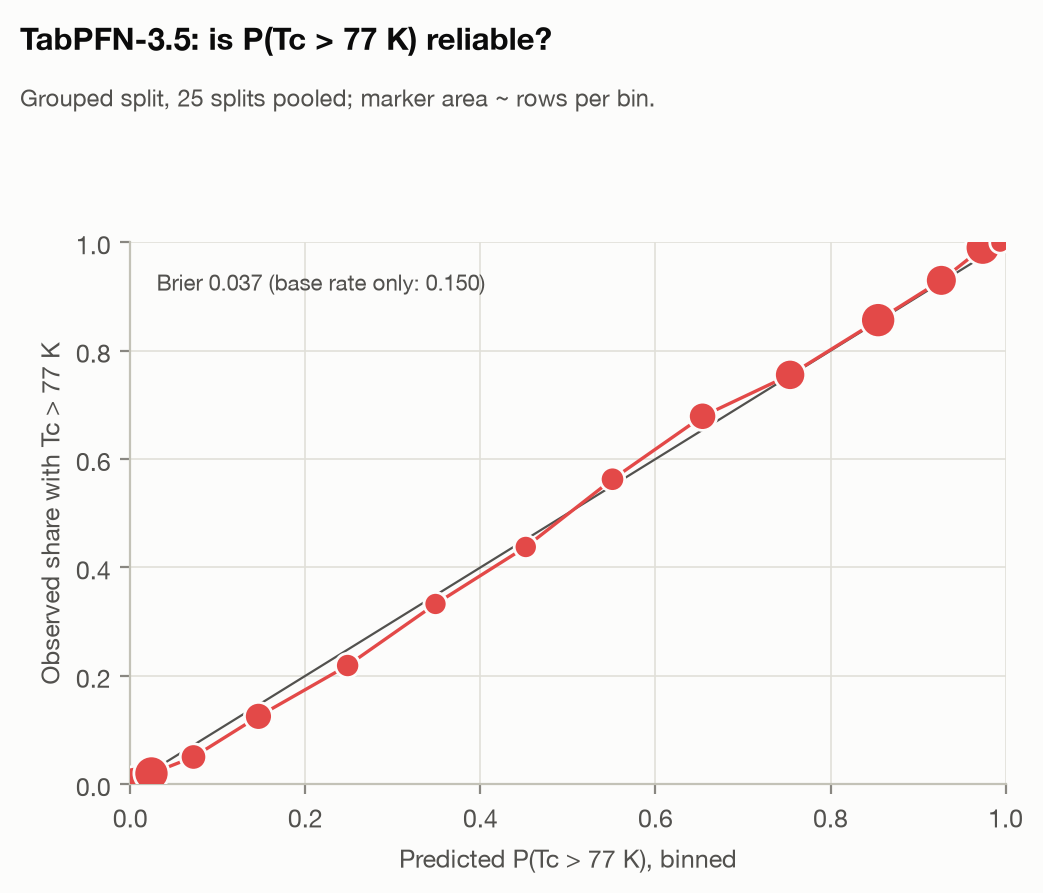

In [7]:
display(pd.read_csv(UNC / "p77_brier.csv").round(4))
display(Image(FIG / "p77_reliability.png"))

## 6. Leave-family-out: do the intervals know when the model is extrapolating?
Coverage and width on each held-out family, next to the same family in-distribution (grouped
split), and the per-row rank correlation between 95% interval width and absolute error.

,model,features,held_out_family,n,held_out_coverage_95%,in_distribution_coverage_95%,held_out_coverage_80%,in_distribution_coverage_80%,held_out_width_95%,in_distribution_width_95%,width_error_spearman
0,tabpfn,engineered,cuprate,10532,0.846,0.949,0.390,0.808,92.849,41.269,0.232
1,tabpfn,engineered,iron-based,1682,0.383,0.954,0.127,0.799,17.520,23.367,0.040
2,tabpfn,engineered,other,9049,0.856,0.955,0.527,0.822,89.865,9.601,0.490
3,tabpfn,composition,cuprate,10532,0.783,0.956,0.358,0.820,89.342,42.942,0.009
4,tabpfn,composition,iron-based,1682,0.598,0.954,0.222,0.805,29.743,24.952,0.078
5,tabpfn,composition,other,9049,0.946,0.962,0.521,0.834,113.243,9.391,0.574


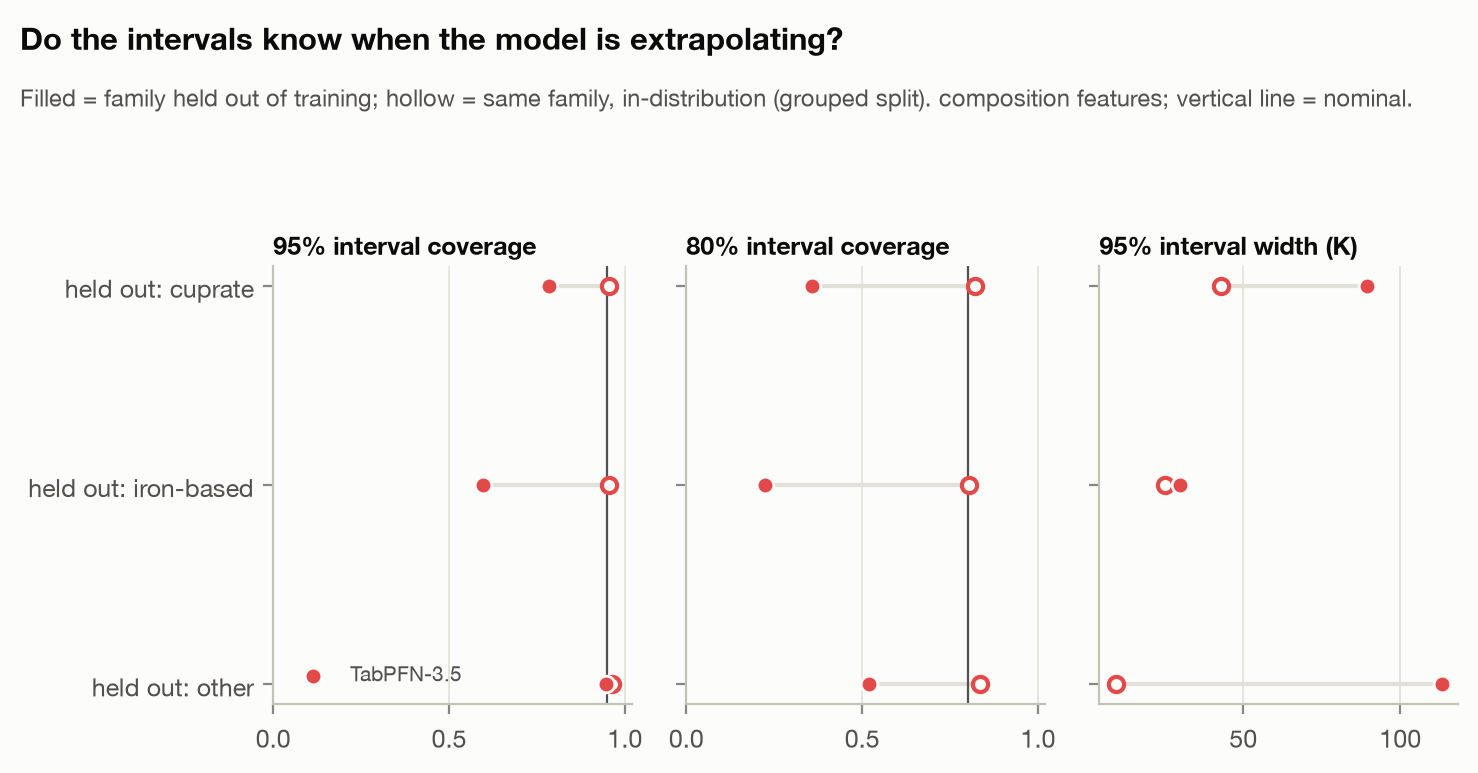

In [8]:
lfo = pd.read_csv(UNC / "lfo.csv")
keep = [
    "model",
    "features",
    "held_out_family",
    "n",
    "held_out_coverage_95%",
    "in_distribution_coverage_95%",
    "held_out_coverage_80%",
    "in_distribution_coverage_80%",
    "held_out_width_95%",
    "in_distribution_width_95%",
    "width_error_spearman",
]
display(lfo[keep].round(3))
display(Image(FIG / "lfo_coverage.png"))